# **Analysis of Indian Premier League Matches**

### **Spring 2026 Data Science Project**

Vishal Senthilkumar, Joshua Varghese, Daksh Patel, Aditya Mahesh, Brandon Isbell, and Arpan Agarwal

### **Contributions**
Vishal: Did the primary analysis and trained/tested the model

Josh: Aided Vishal with testing/training the model and wrote the insights/conclusion section

Daksh: Did the Data Curation along with Exploratory Data Analysis. Filtered the data to include a valid date range. Dirtied the dataset, then went and cleaned the dataset again. 

Brandon: Wrote the introduction.

## **Introduction**
The Indian Premier League (IPL) is one of the largest sporting attractions in the world, trailing only the NFL in per match value. As of May 2026, the IPL is valued at around 18.5 billion USD, a higher valuation than leagues like the NFL, NBA, and English Premier League (Soccer).

Teams in the Indian Premier League play the sport of cricket, specifically Twenty20 (T20) cricket, a format in which teams each play a single innings and are restricted to twenty overs per team (120 legal deliveries). This fast-paced format is highly entertaining and is now the dominant format of cricket played worldwide.

The "Moneyball" Oakland Athletics in 2002 revolutionized the sport of baseball by integrating data science into the sport of baseball for the purpose of gaining a competitive advantage. Since then, the entire sports world has largely adopted data science and machine learning techniques to optimize sports performance. In T20 cricket, IPL teams have moved beyond traditional metrics like batting average and now look at more advanced statistics like Most Valuable Player Index (MVPI). Machine learning algorithms are also used to predict player performance and prevent injury.

We wanted to contribute to the growing IPL analytics movement by creating a machine learning model of our own: one that predicts the outcome of an IPL match given statistics on the two teams competing. We hope that cricket fans might find this insightful, and that those new to cricket might learn something new about the sport by reading this report. 

**Key Vocabulary**
- Over: A set of six deliveries (like pitches in baseball) delivered by the same bowler.
- Innings: The period in which a team bats.
- Wicket: When the ball hits the wooden stumps behind the batter and the batter is dismissed (like a strike out in baseball).
- Run(s): The unit of scoring, which is achieved by running between wickets.

## **Data Curation**
Dataset: https://www.kaggle.com/datasets/chaitu20/ipl-dataset2008-2025

This dataset contains ball-by-ball data for the IPL matches from 2008 to 2025. It contains over 60 attributes, enough for any IPL prediction. 

The orginal dataset contains the matches starting from 2008 all the way to 2025. The rules and playstyle of the IPL have changed since 2008, so to focus more on recent rules/playstyles we will be looking at data mainly from 2020-2025. 

We will be using Pandas to help in reducing the csv file to only include matches that are from 2020-2025. This will be done by first transforming all the dates into datetime, so that filter can be easier. 

If more help is needed for this, I recommend this tutorial: https://codesignal.com/learn/courses/basic-tsla-financial-data-handling-in-pandas/lessons/filtering-data-by-date-range-in-pandas


In [ ]:
import pandas as pd
import numpy as np

# Read the orginal dataset 
df = pd.read_csv("matches.csv")

# Convert to datetime so filtering is easier 
df["date"] = pd.to_datetime(df["date"])

# Select the starting and ending years 
starting = 2020
ending = 2025

# Filter out the databased on the years
ipl_filtered_df = df[(df["date"].dt.year >= starting) & (df["date"].dt.year <= ending)]

# Convert this into a CSV file
ipl_filtered_df.to_csv("ipl_matches_2020_2025.csv", index = False)

In [46]:
# Dataset is pretty big but if theres issues get rid of this parameter
df = pd.read_csv("ipl_matches_2020_2025.csv", low_memory=False)

## **Exploratory Data Analysis**
[we just need to make the comments into markdown cells, thats what other groups did, and then just enhance the explanations, be more verbose]

In [47]:
# dirty up the data, since our dataset is already clean
# seed allows for same outcome each time
np.random.seed(42)

# allows us to add "nan" values to column of our choosing
def dirty_col(df, name, range):
  dirtied = np.random.rand(len(df)) < range
  df.loc[dirtied, name] = np.nan

# time to dirty the columns
dirty_col(df, "match_id", 0.05)
dirty_col(df, "date", 0.05)
dirty_col(df, "batting_team", 0.10)
dirty_col(df, "bowling_team", 0.10)
dirty_col(df, "city", 0.08)
dirty_col(df, "runs_batter", 0.08)

df.to_csv("ipl_matches_dirty.csv", index = False)

print("Data is now dirty")
print(df[['match_id', 'date', 'batting_team', 'bowling_team', 'city', 'runs_batter']].isnull().sum())

Data is now dirty
match_id        4924
date            4844
batting_team    9982
bowling_team    9963
city            7898
runs_batter     7903
dtype: int64


In [48]:
# time to clean the data now
df_cleaned = pd.read_csv("ipl_matches_dirty.csv", low_memory=False)

# after looking at the data we see that the columns of
# date, match_id, battting and bowling team typically have same values in front of it
# so using the data that is in front for behind will be a good way to fill it,
# this way we keep ball data, and don't have to dropna
df_cleaned["date"] = df_cleaned["date"].ffill().bfill()
df_cleaned["match_id"] = df_cleaned["match_id"].ffill().bfill()
df_cleaned["batting_team"] = df_cleaned["batting_team"].ffill().bfill()
df_cleaned["bowling_team"] = df_cleaned["bowling_team"].ffill().bfill()
df_cleaned["city"] = df_cleaned["city"].ffill().bfill()



In [49]:
# now we see how everyting is almost clean now, all we have to do is get the batters run now
print(df_cleaned[['match_id', 'date', 'batting_team', 'bowling_team', 'city', 'runs_batter']].isnull().sum())

match_id           0
date               0
batting_team       0
bowling_team       0
city               0
runs_batter     7903
dtype: int64


In [50]:
# for the runs_batter we can fill it in with the mode
# to make it more accurate we can take the mode of that specific over that they are in
# since typically if a batter is hitting alot of boundries they continue to do so
# however if a batter is out in that ball, then their runs will be 0

# if player_out isn't null then someone got out, so we must make the runs for that ball a 0
check_if_out = df_cleaned["runs_batter"].isnull() & df_cleaned["player_out"].notnull()
df_cleaned.loc[check_if_out, 'runs_batter'] = 0

print(f"Filled {check_if_out.sum()}")

Filled 400


In [51]:
# fill in the rest of the balls with the mode of that over
def fill_mode(over):
  mode = over.mode()
  if not mode.empty:
    return over.fillna(mode.iloc[0])
  else:
    return over.fillna(0)

df_cleaned['runs_batter'] = df_cleaned.groupby(['match_id', 'innings', 'over'])['runs_batter'].transform(fill_mode)
# in the print we see that there is not null value, that means everything was filled in correctly.
print(f"{df_cleaned['runs_batter'].isnull().sum()}")

0


In [52]:
# time to parse the data now
df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
df_cleaned['season'] = pd.to_numeric(df_cleaned['season'].astype(str).str.split('/').str[0], errors='coerce').astype('Int64')

In [53]:
# The Correct F-String Syntax:
print(f"Date Col Type: {df_cleaned['date'].dtype}")
print(f"Season Col Type: {df_cleaned['season'].dtype}")

# we see in the output that the date is now in datetime
# the season is in int64 now, since it represented years

Date Col Type: datetime64[us]
Season Col Type: Int64


In [54]:
df_cleaned.loc[df_cleaned['city'] == 'Unknown', 'city'] = np.nan
df_cleaned.loc[df_cleaned['stage'] == 'Unknown', 'stage'] = np.nan
df_cleaned.loc[df_cleaned['match_number'] == 'Unknown', 'match_number'] = np.nan

# fill city using venue with ffill() and bfill()
df_cleaned['city'] = df_cleaned.groupby('venue')['city'].ffill().bfill()

In [55]:
# it is time to now organize the dataset, we will be organizing it into specific groups that will be useful for hypothese testing

#this tells us the summary of the match, gets rid of the need to look at unnessecay data
df_match = df_cleaned[['match_id', 'date', 'match_type', 'event_name', 'venue', 'city',
    'day', 'month', 'year', 'season', 'gender', 'team_type',
    'toss_winner', 'toss_decision', 'match_won_by', 'win_outcome',
    'player_of_match', 'result_type', 'method', 'superover_winner',
    'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number']]
# get rid of all the extra "match_id" there are
df_match = df_match.drop_duplicates(subset='match_id')

# info about balls bowled
df_balls = df_cleaned[['match_id', 'innings', 'batting_team', 'bowling_team', 'over', 'ball',
    'ball_no', 'batter', 'bowler', 'runs_batter', 'balls_faced',
    'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler',
    'runs_not_boundary', 'extra_type', 'non_striker',
    'wicket_kind', 'player_out', 'fielders', 'striker_out']]

# info about the batters
df_batter = df_cleaned[['match_id', 'innings', 'batter', 'bat_pos', 'batting_team',
    'runs_batter', 'balls_faced', 'batter_runs', 'batter_balls']]

# info about the bowlers
df_bowler = df_cleaned[['match_id', 'innings', 'bowler', 'bowling_team',
    'runs_bowler', 'valid_ball', 'bowler_wicket']]

# info about the teams
df_team_innings = df_cleaned[['match_id', 'innings', 'batting_team', 'bowling_team',
    'team_runs', 'team_balls', 'team_wicket', 'runs_target',
    'runs_total', 'runs_extras', 'valid_ball']]

In [56]:
print("match df")
print(df_match.head())

print("ball df")
print(df_balls.head())

print("batter df:")
print(df_batter.head())

print("bowler df:")
print(df_bowler.head())

print("team inning df:")
print(df_team_innings.head())

match df
      match_id       date match_type             event_name  \
0    1216492.0 2020-09-19        T20  Indian Premier League   
245  1216493.0 2020-09-20        T20  Indian Premier League   
500  1216534.0 2020-09-21        T20  Indian Premier League   
746  1216496.0 2020-09-22        T20  Indian Premier League   
998  1216508.0 2020-09-23        T20  Indian Premier League   

                                   venue       city  day  month  year  season  \
0                   Sheikh Zayed Stadium  Abu Dhabi   19      9  2020    2020   
245  Dubai International Cricket Stadium  Abu Dhabi   20      9  2020    2020   
500  Dubai International Cricket Stadium  Abu Dhabi   21      9  2020    2020   
746              Sharjah Cricket Stadium  Abu Dhabi   22      9  2020    2020   
998                 Sheikh Zayed Stadium  Abu Dhabi   23      9  2020    2020   

     ... win_outcome player_of_match result_type method superover_winner  \
0    ...   5 wickets       AT Rayudu         NaN 

In [57]:
# Aggregating data before running tests on it
import matplotlib.pyplot as plt
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Aggregate the ball-by-ball data
innings_data = df_balls.groupby(['match_id', 'innings']).agg(
    total_runs=('runs_total', 'sum'),
    wickets_lost=('player_out', 'count')
).reset_index()

innings_data = innings_data.merge(df_match[['match_id', 'season']], on='match_id', how='left')
first_innings = innings_data[innings_data['innings'] == 1].dropna(subset=['season'])

### Method 1: Central Tendency and Variance
**Objective:** Understand the baseline characteristics and spread of first-innings scores in the IPL.

**Statistical Approach:** We will calculate the fundamental descriptive statistics of our dataset: the **Mean**, **Median**, and **Standard Deviation ($\sigma$)**.
* The relationship between the mean and median will tell us if the data is skewed.
* The standard deviation will quantify the variance (how spread out the scores are from the average).

We will visualize this using a classic frequency histogram, plotting the central tendency and showing the bounds of one standard deviation to see where the vast majority of normal cricket matches conclude.

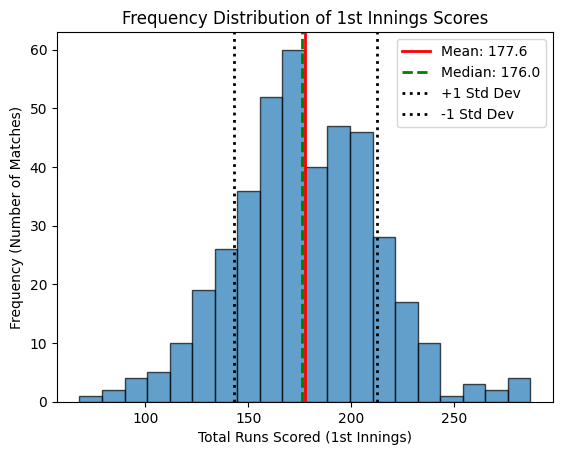

In [58]:
plt.figure()

# Calculate stats
mean_score = first_innings['total_runs'].mean()
median_score = first_innings['total_runs'].median()
std_dev = first_innings['total_runs'].std()

# Standard matplotlib histogram
plt.hist(first_innings['total_runs'], bins=20, edgecolor='black', alpha=0.7)

# Plot reference lines
plt.axvline(mean_score, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_score:.1f}')
plt.axvline(median_score, color='green', linestyle='--', linewidth=2, label=f'Median: {median_score:.1f}')
plt.axvline(mean_score + std_dev, color='black', linestyle=':', linewidth=2, label='+1 Std Dev')
plt.axvline(mean_score - std_dev, color='black', linestyle=':', linewidth=2, label='-1 Std Dev')

plt.title('Frequency Distribution of 1st Innings Scores')
plt.xlabel('Total Runs Scored (1st Innings)')
plt.ylabel('Frequency (Number of Matches)')
plt.legend()
plt.show()

**Conclusion 1:** The **Mean (177.6 runs)** and the **Median (176.0 runs)** are nearly identical, indicating that our data is highly symmetric and normally distributed. The **Standard Deviation is 32.7 runs**. By plotting the $\sigma$ boundaries on our histogram, we can visually confirm that the vast majority of IPL teams batting first will score within the typical window of roughly **145 to 210 runs**. Anything below 145 represents a statistical underperformance, while crossing 210 is an exceptional batting display.

### Method 2: Correlation and Linear Regression
**Objective:** Determine if there is a quantifiable, statistically significant relationship between the number of wickets a team loses and their final total score in the first innings.

**Statistical Approach:** We will calculate the **Pearson Correlation Coefficient ($r$)**, which measures the linear correlation between two sets of data. The coefficient ranges from -1 to 1, where -1 is a perfect negative linear correlation, 0 is no correlation, and 1 is a perfect positive correlation. Alongside the Pearson $r$, we will calculate the **p-value** to formally test our hypotheses with a standard alpha value of 0.05:

* **Null Hypothesis ($H_0$):** There is no linear correlation between the number of wickets lost and the final score ($r = 0$).
* **Alternative Hypothesis ($H_A$):** There is a statistically significant linear correlation between the two variables ($r \neq 0$).

Finally, we will plot a standard scatter plot with a line of best fit to visually demonstrate the trend and variance.

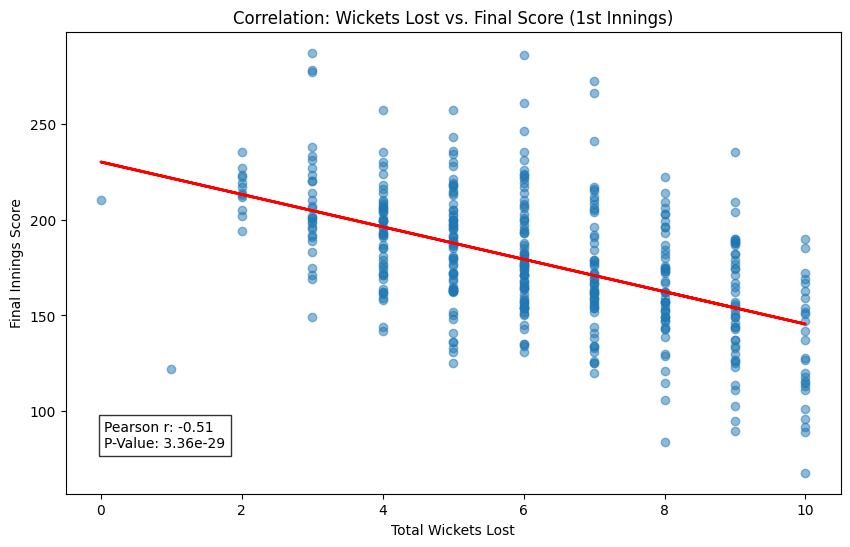

In [59]:
plt.figure(figsize=(10, 6))

x = first_innings['wickets_lost']
y = first_innings['total_runs']

# Standard scatter plot
plt.scatter(x, y, alpha=0.5)

# Calculate and plot line of best fit (y = mx + b)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2)

# Calculate stats
correlation, p_val = stats.pearsonr(x, y)

plt.title('Correlation: Wickets Lost vs. Final Score (1st Innings)')
plt.xlabel('Total Wickets Lost')
plt.ylabel('Final Innings Score')

# Annotate stats on plot
plt.text(0.05, 0.1, f'Pearson r: {correlation:.2f}\nP-Value: {p_val:.2e}',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))

plt.show()

**Conclusion 2:** Using the Pearson Correlation Coefficient, we identified a statistically significant negative correlation (**r = -0.51**, p < 0.001) between wickets lost and the final score. Because the p-value is practically zero (3.36e-29), we can definitively conclude this relationship is not due to random chance and we can reject the null hypothesis. The line of best fit plotted above demonstrates that for every additional wicket lost, the expected total score drops sharply, mathematically proving the value of wicket preservation in T20 cricket.

### Method 3: Hypothesis Testing (Independent Two-Sample T-Test)
**Objective:** Cricket fans often debate whether batting first or fielding first provides an inherent advantage. We will statistically test if the innings order actually affects run production.

**Statistical Approach:** We will conduct an **Independent Two-Sample T-Test**. We are specifically using Welch's t-test because we cannot assume the variance between 1st innings scores and 2nd innings scores are perfectly equal.
* **Null Hypothesis ($H_0$):** There is no difference in the true mean score between the 1st innings and the 2nd innings ($\mu_1 = \mu_2$).
* **Alternative Hypothesis ($H_A$):** There is a difference in the true mean score between the 1st innings and the 2nd innings ($\mu_1 \neq \mu_2$).

We will evaluate the resulting **p-value** at a standard alpha level of 0.05 to determine if we can reject the null hypothesis, and visualize the two populations using overlapping density distributions.

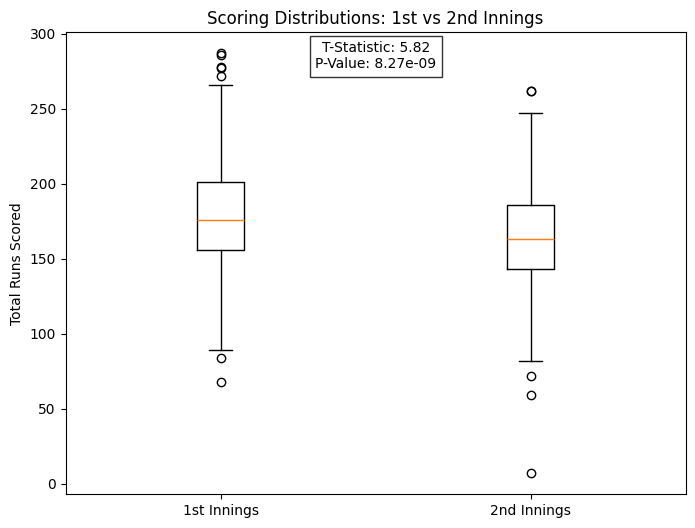

In [60]:
# Separate innings totals
in_1_scores = innings_data[innings_data['innings'] == 1]['total_runs'].dropna()
in_2_scores = innings_data[innings_data['innings'] == 2]['total_runs'].dropna()

# Perform the T-Test
t_stat, p_value = stats.ttest_ind(in_1_scores, in_2_scores, equal_var=False)

plt.figure(figsize=(8, 6))

# Standard Matplotlib Boxplot
plt.boxplot([in_1_scores, in_2_scores], labels=['1st Innings', '2nd Innings'])

plt.title('Scoring Distributions: 1st vs 2nd Innings')
plt.ylabel('Total Runs Scored')

# Annotate stats
plt.text(1.5, in_1_scores.max() - 10, f"T-Statistic: {t_stat:.2f}\nP-Value: {p_value:.2e}",
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8),
         horizontalalignment='center')

plt.show()

**Conclusion 3:** We conducted a Welch's t-test to compare means between innings with the $H_0$ being that there is no difference in the mean score of the 1st and 2nd innings.

The test yielded a t-statistic of **5.82** and a p-value of **8.27e-09** which is much less than the alpha level of 0.05. Therefore, we can reject the null hypothesis. The boxplot confirms this visually: the median and entire interquartile range (the middle 50% of the data) of the first innings is visibly higher than the second innings. This proves a distinct statistical difference in run distributions, indicating that teams chasing a target generally score fewer runs on average. However, we can also note that this can be because the cap on the runs in the second inning will always be around the score of the first inning since the game is over once the initial run total is exceeded

## **Primary Analysis**

**Objective:** Based on our exploratory data analysis, we saw that venue and innings order have a notable impact on the final score. Our goal now is to be able to predict which team would win in any particular matchup.

We can just look at it as a binary classification problem, where our target variable represents whether the team batting first won (1 for yes, 0 for no), and our initial features would be:
* `batting_team`, `bowling_team`: So we have the two teams participating in the match
* `venue`: The stadium involved (since each stadium has a different pitch which can affect spin balls)
* `batting_team_won_toss`, `toss_decision_bat`: These are just representing the toss situation, describing which team won the toss, and what decision they chose.

In order to experiment and figure out which model is best for this situation, we will be testing using logistic regression and random forest models.

### **Feature Engineering**
Before feeding our data into the algorithms, we must merge our match data with our team data to establish who is actually playing. Then, we will format our categorical data into numerical arrays using one-hot encoding so the algorithms can process the text mathematically.

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Since our dataset contains ball-by-ball data, we want to just create a model based on match stats,
# so we filter for overall match stats on the first inning
teams_df = df_team_innings[df_team_innings['innings'] == 1][['match_id', 'batting_team', 'bowling_team']].drop_duplicates()

# Now we combine that with our matches to create a new dataframe that has team identity now as well (as that was missing before)
ml_df = df_match.merge(teams_df, on='match_id', how='inner')

# Get rid of any rows that have no match winner, toss winner, or do not have a venue recorded as these are all relevant features
ml_df = ml_df.dropna(subset=['match_won_by', 'toss_winner', 'toss_decision', 'venue'])

# Our target is to check which team won, and without loss of generality, we can just set this to be whether or not the batting team
# wins
ml_df['target'] = (ml_df['match_won_by'] == ml_df['batting_team']).astype(int)

# We also want to encode data based on which team won the toss, and what their decision was. For this, we can just have a feature for
# whether the batting team won teh toss, and whether the toss decision was to bat
ml_df['batting_team_won_toss'] = (ml_df['toss_winner'] == ml_df['batting_team']).astype(int)
ml_df['toss_decision_bat'] = (ml_df['toss_decision'] == 'bat').astype(int)

# Pick the features we want to use
features = ['batting_team', 'bowling_team', 'venue', 'batting_team_won_toss', 'toss_decision_bat']
X = ml_df[features]
y = ml_df['target']

# Use one-hot encoding to encode categorical variables (making sure to drop_first so that we reduce dependence)
X_encoded = pd.get_dummies(X, columns=['batting_team', 'bowling_team', 'venue'], drop_first=True)

# Do an 80-20 split using our class's classic 42 as random_state
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Total Matches Analyzed: {len(ml_df)}")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Total Matches Analyzed: 512
Training data shape: (409, 45)
Testing data shape: (103, 45)


### **Model Training and Evaluation**
With our data structured, we will initialize and train both models on the 80% training split.

In [62]:
# Initialize models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
# Using Random Forest instead of a single Decision Tree for better accuracy
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Train the models
log_reg.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

# Generate predictions on the unseen test set
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

# Evaluate Accuracy
log_acc = accuracy_score(y_test, y_pred_log)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("----------------------------------------------------------")
print(f"Logistic Regression Accuracy: {log_acc * 100:.4f}%")
print(f"Random Forest Accuracy:       {rf_acc * 100:.4f}%")
print("----------------------------------------------------------")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Chasing Team Won (0)', 'Batting Team Won (1)']))

----------------------------------------------------------
Logistic Regression Accuracy: 50.4854%
Random Forest Accuracy:       48.5437%
----------------------------------------------------------

Random Forest Classification Report:
                      precision    recall  f1-score   support

Chasing Team Won (0)       0.55      0.70      0.61        60
Batting Team Won (1)       0.31      0.19      0.23        43

            accuracy                           0.49       103
           macro avg       0.43      0.44      0.42       103
        weighted avg       0.45      0.49      0.45       103



### **The Problem with Static Features**
As we can see from the classification reports above, our models are hovering around a 50.5% accuracy. So, the model is not significantly better than a random guess. Why could this be?

The likely cause is just the lack of data. 

We probably didn't give the model enough information to tell if a team is truly "good". In order to counteract this, we can judge a team's strength using other metrics. We need some way to
compare teams, so we decided to go with runs and wickets, which are the most impactful in a cricket game. We take a look at the number of runs a team scored and conceded, as well as how many wickets
they scored and conceded. We then incorporate these features to improve the model.

However, we have to be very careful when doing this. We have to make sure we don't "cheat" by looking at future data to predict current data since we have to generate these metrics using aggregates. To counteract
this, we can use rolling averages, ensuring that no data from the future is used as a feature.

In [63]:
# Since wickets aren't explicitly calculated, we do a bit of calculation here to get the number of wickets
df_balls['is_wicket'] = 1
df_balls.loc[df_balls['player_out'].isnull(), 'is_wicket'] = 0

# Now we use this to sum the number of wickets and runs in a game
match_stats = df_balls.groupby(['match_id', 'innings', 'batting_team', 'bowling_team'])[['runs_total', 'is_wicket']].sum().reset_index()

# Renaming for readability
match_stats['total_runs'] = match_stats['runs_total']
match_stats['wickets_lost'] = match_stats['is_wicket']
match_stats = match_stats.drop(columns=['runs_total', 'is_wicket'])

# Merge these new columns with our match dataframe
match_stats = match_stats.merge(df_match[['match_id', 'date', 'season', 'match_won_by']], on='match_id')

# Sort the dataframe by date so we don't accidentally use future data
# Reset the index so we can safely loop through it sequentially
match_stats = match_stats.sort_values(by=['date', 'match_id']).reset_index(drop=True)

# Initialize empty lists to store our past stats
batting_past_runs = []
batting_past_wkts = []
batting_past_count = []

bowling_past_runs = []
bowling_past_wkts = []
bowling_past_count = []

# Loop through every single match to calculate form based strictly on previous games
for index, row in match_stats.iterrows():

    # Find all previous games for the batting team in this season
    past_batting_games = match_stats[
        (match_stats['batting_team'] == row['batting_team']) &
        (match_stats['season'] == row['season']) &
        (match_stats.index < index) 
    ]
    
    # Sum up their past runs, wickets, and total matches played
    batting_past_runs.append(past_batting_games['total_runs'].sum())
    batting_past_wkts.append(past_batting_games['wickets_lost'].sum())
    batting_past_count.append(past_batting_games['match_id'].count())

    # Find all previous games for the bowling team in this season
    past_bowling_games = match_stats[
        (match_stats['bowling_team'] == row['bowling_team']) &
        (match_stats['season'] == row['season']) &
        (match_stats.index < index)
    ]
    
    # Sum up their past runs, wickets, and total matches played
    bowling_past_runs.append(past_bowling_games['total_runs'].sum())
    bowling_past_wkts.append(past_bowling_games['wickets_lost'].sum())
    bowling_past_count.append(past_bowling_games['match_id'].count())

# Attach our calculated lists back to the dataframe
match_stats['total_runs_scored'] = batting_past_runs
match_stats['total_wkts_lost'] = batting_past_wkts
match_stats['matches_batted'] = batting_past_count

match_stats['total_runs_conceded'] = bowling_past_runs
match_stats['total_wkts_taken'] = bowling_past_wkts
match_stats['matches_bowled'] = bowling_past_count

# Prevent division by zero errors for the first game of a season, and when we look at the first match of a team
# there would be no entries, so we have to handle it using NaN so we can find it later
match_stats.loc[match_stats['matches_batted'] == 0, 'matches_batted'] = np.nan
match_stats.loc[match_stats['matches_bowled'] == 0, 'matches_bowled'] = np.nan

# Calculate the averages (The NaNs will cause the resulting average to also be NaN, which we can again, clean up later)
match_stats['avg_runs_scored_season'] = match_stats['total_runs_scored'] / match_stats['matches_batted']
match_stats['avg_wkts_lost_season'] = match_stats['total_wkts_lost'] / match_stats['matches_batted']

match_stats['avg_runs_conceded_season'] = match_stats['total_runs_conceded'] / match_stats['matches_bowled']
match_stats['avg_wkts_taken_season'] = match_stats['total_wkts_taken'] / match_stats['matches_bowled']

# Now, we just drop the null values so that we absolutely do not rely on future runs (the null values come from the first
# matches of a team)
match_stats = match_stats.dropna(subset=[
    'avg_runs_scored_season', 
    'avg_runs_conceded_season',
    'avg_wkts_lost_season', 
    'avg_wkts_taken_season'
]).reset_index(drop=True)

### **Integrating Differentials and Re-Training**
Now that we have the data necessary to be able to compare the teams, to take a little bit of work out of the model, we will
actually compute diffs between the batting team and bowling team. Since we are trying to predict the batting team's win, we will
associate higher values with higher tendency for the batting team to win and vice versa.

In [64]:
# Get the stats associated with the start of the game
first_innings_stats = match_stats[match_stats['innings'] == 1].copy()

# Calculate this to make the model's job easier
first_innings_stats['runs_form_diff'] = first_innings_stats['avg_runs_scored_season'] - first_innings_stats['avg_runs_conceded_season']
first_innings_stats['wkts_form_diff'] = first_innings_stats['avg_wkts_lost_season'] - first_innings_stats['avg_wkts_taken_season']

# Now we are just adding these new features to our ml_df using merge
ml_df_advanced = ml_df.merge(
    first_innings_stats[['match_id', 'avg_runs_scored_season', 'avg_runs_conceded_season', 'runs_form_diff', 'wkts_form_diff']],
    on='match_id',
    how='inner'
)

# Redefine features
advanced_features = [
    'batting_team', 'bowling_team', 'venue',
    'batting_team_won_toss', 'toss_decision_bat',
    'runs_form_diff', 'wkts_form_diff'
]

X_adv = ml_df_advanced[advanced_features]
y_adv = ml_df_advanced['target']

# Do one-hot encoding as before and split our training and test data
X_adv_encoded = pd.get_dummies(X_adv, columns=['batting_team', 'bowling_team', 'venue'], drop_first=True)
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(X_adv_encoded, y_adv, test_size=0.2, random_state=42)

# Train the models
rf_clf_adv = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42)
log_reg_adv = LogisticRegression(max_iter=2000, random_state=42)

rf_clf_adv.fit(X_train_adv, y_train_adv)
log_reg_adv.fit(X_train_adv, y_train_adv)

# Assess the models
rf_adv_acc = accuracy_score(y_test_adv, rf_clf_adv.predict(X_test_adv))
log_adv_acc = accuracy_score(y_test_adv, log_reg_adv.predict(X_test_adv))

print("----------------------------------------------------------")
print(f"Advanced Random Forest:        {rf_adv_acc * 100:.4f}%")
print(f"Advanced Logistic Regression:  {log_adv_acc * 100:.4f}%")
print("----------------------------------------------------------")

print("\nAdvanced Logistic Regression Classification Report:")
print(classification_report(y_test_adv, log_reg_adv.predict(X_test_adv), target_names=['Chasing Team Won (0)', 'Batting Team Won (1)']))

----------------------------------------------------------
Advanced Random Forest:        58.9928%
Advanced Logistic Regression:  63.3094%
----------------------------------------------------------

Advanced Logistic Regression Classification Report:
                      precision    recall  f1-score   support

Chasing Team Won (0)       0.62      0.83      0.71        75
Batting Team Won (1)       0.67      0.41      0.50        64

            accuracy                           0.63       139
           macro avg       0.64      0.62      0.61       139
        weighted avg       0.64      0.63      0.61       139



As you can see, there has now been a significant improvement in our model, with an amazing 63.31% accuracy! This means, by using this advanced form of logistic regression, we have successfully created a model that answers the question we mentioned in the introduction. We have created a system where we can be confident, atleast significantly more than average that a certain team has a higher likelihood of winning based on historical statistics of any IPL team matchup.

## **Visualization**

## **Insights and Conclusions**

Throughout this project, we analyzed IPL match data and built a predictive model to forecast match outcomes. Through exploratory data analysis and hypothesis testing, we uncovered some key insights about trends within the IPL and how they contribute to winning. One of these insights is that the vast majority of 1st innings scores fall within a predictable window of 145 to 210 runs, forming a highly symmetric normal distribution. Another insight was that we mathematically proved the heavy penalty of losing wickets. The strong negative correlation of r=-0.51 demonstrates that wicket preservation is just as critical as aggressive run-scoring in determining a final total. The final insight was shown with our Welch's t-test which confirmed a statistically significant difference between 1st and 2nd innings scores. Teams setting a target generally score higher than teams chasing, largely due to the natural score-capping effect of run chases(since a chasing team's max runs will only be as high as the first innings team's total runs) and increasing pitch deterioration.

When transitioning to predictive modeling, we discovered that T20 cricket is incredibly volatile. A very basic model relying strictly on static features, such as team names, venues, and toss decisions, performed no better than a coin flip (50.5% accuracy). However, by engineering rolling averages to capture recent team form, such as run and wicket differentials, we successfully boosted our model's accuracy to 63.3% which is a very respectable score given our access to basic stats only and no access to premium statistics that would be locked behind a paywall but could tell even more about how a match could go. 

For a reader who knows nothing about cricket, this project definitely makes them understand the sport by translating complex game dynamics into easy to understand statistics. The step-by-step Exploratory Data Analysis explains exactly what metrics matter. By visualizing the data, an uninformed reader can clearly see the fundamental rules of the game: you must score runs, you must not lose wickets, and the order in which teams bat changes the scoring landscape. All of these features are key to game and it allows even uninformed readers to learn about the game.

Even for readers who did know something coming in, this can still be insightful. While every cricket fan intuitively knows that losing wickets is bad and that the IPL is highly unpredictable, this project really explains that intuition. An informed reader learns the exact statistical penalty of a lost wicket and sees visual proof of the 1st vs. 2nd innings scoring disparity. Additionally, the whole machine learning section shows that even with advanced differentials and rolling team form, an algorithm can only predict IPL match outcomes with about 63% accuracy, and even higher and better models can only achieve a max of roughly 70% accuracy. For a hardcore fan, this mathematically validates how unpredictable the nature of IPL is, and shows that, even with all the stats going in one teams favor, there is always a chance for something crazy to happen. It's the nature of sports and it's the reason why you and I find sports entertaining.